## Name: Aman Mujahid
## Github Username: amanmujahid
## USC ID: 7092517106

### Problem-1

#### 1(b)(i)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt


df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9568
Number of columns: 5


Each row is one hourly reading from the plant while it was running at full load, and the columns are the variables, AT is ambient temperature in degrees Celsius, V is exhaust vacuum in cm Hg, AP is ambient pressure in millibar, RH is relative humidity in percent, and PE is the net hourly electrical output.

#### 1(b)(ii)

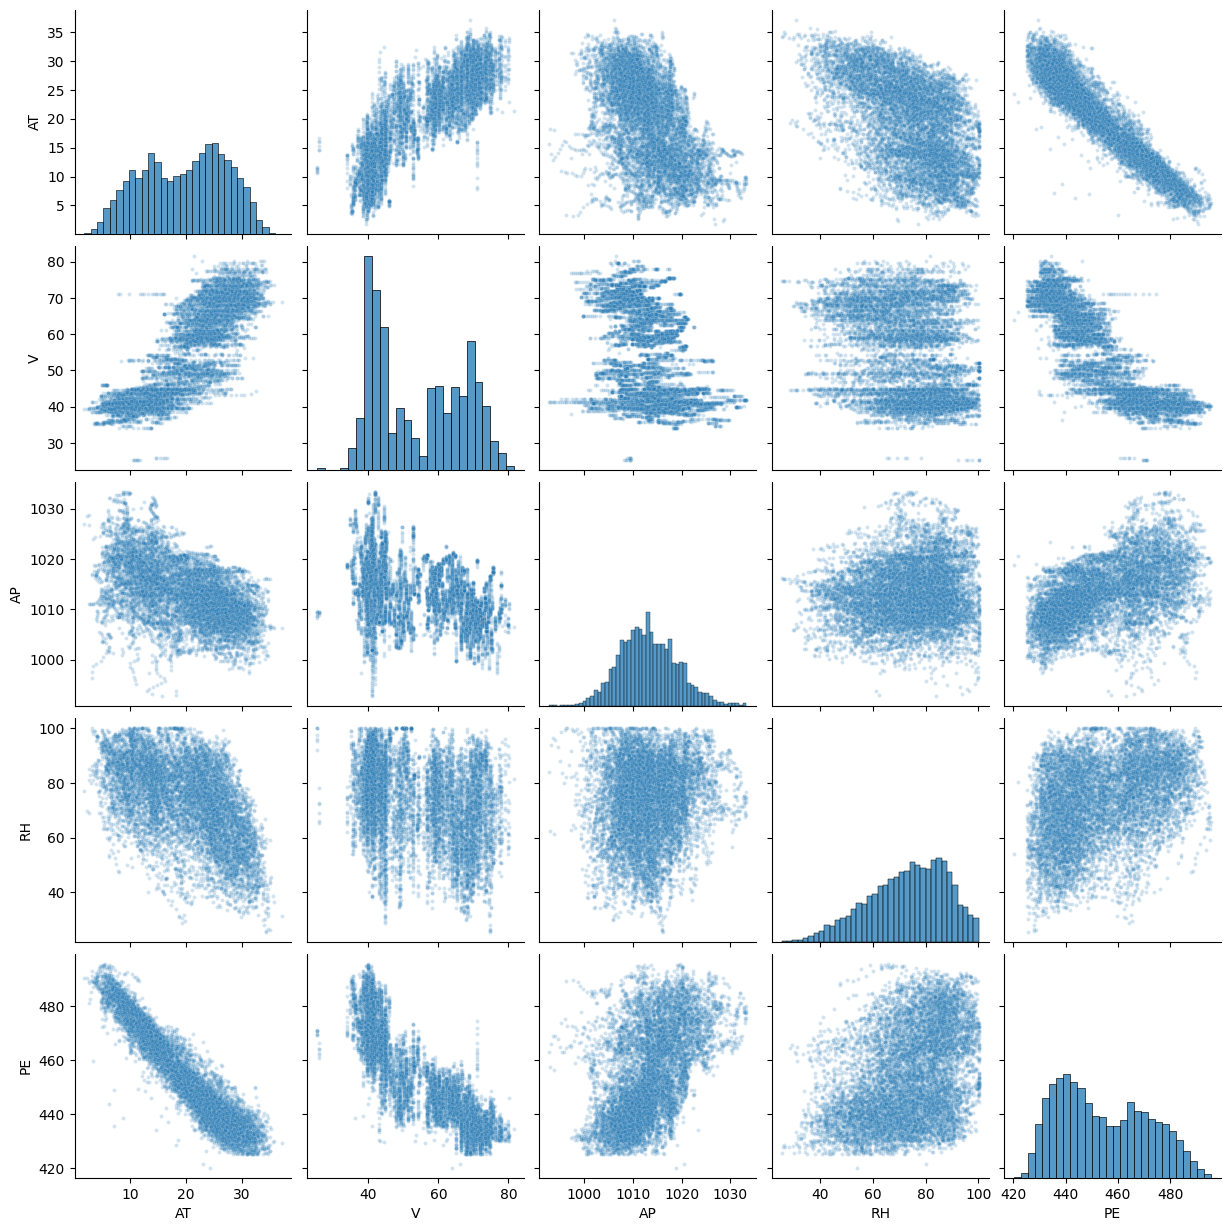

In [3]:
sns.pairplot(df, plot_kws={"s": 8, "alpha": 0.2})
plt.show()

In [4]:
df.corr()

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


AT here has the strongest relationship with PE, which is a negative trend that is close to linear, with a correlation of about -0.95. V is also strongly negative here, which is around -0.87. AP and RH are both weaker and positive, at about 0.52 and 0.39, with more scatter in their plots. AT and V are also fairly correlated with each other, which is around 0.84.

#### 1(b)(iii)

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Range": df.max() - df.min(),
    "First Quartile": df.quantile(0.25),
    "Third Quartile": df.quantile(0.75),
    "Interquartile Range": df.quantile(0.75) - df.quantile(0.25)
})
summary.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile,Third Quartile,Interquartile Range
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


#### 1(c)

In [6]:
predictors = ["AT", "V", "AP", "RH"]

results = {}
rows = []

for i in predictors:
    
    reg = stats.linregress(df[i], df["PE"])
    fitted = reg.intercept+reg.slope*df[i]
    resid = df["PE"]-fitted
    results[i] = {"intercept": reg.intercept, "slope": reg.slope, "R2": reg.rvalue**2, "p_value": reg.pvalue, "fitted": fitted, "resid": resid}
    rows.append({"predictor": i, "intercept": reg.intercept, "slope": reg.slope, "R2": reg.rvalue**2, "p_value": reg.pvalue})

pd.DataFrame(rows).set_index("predictor").round(4)

,intercept,slope,R2,p_value
predictor,,,,
AT,497.0341,-2.1713,0.8989,0.0
V,517.8015,-1.1681,0.7565,0.0
AP,-1055.2610,1.4899,0.2688,0.0
RH,420.9618,0.4557,0.1519,0.0


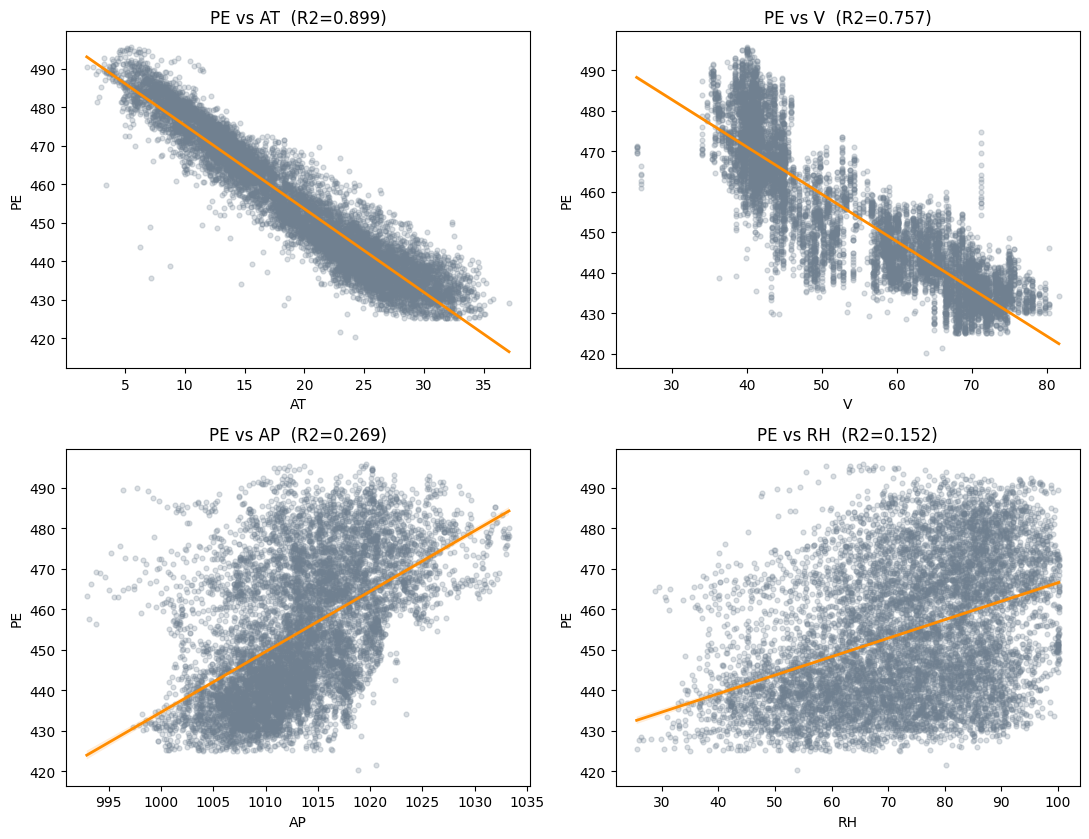

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for ax, p in zip(axes.ravel(), predictors):
    sns.regplot(x=p, y="PE", data=df, ax=ax,
                scatter_kws={"s": 12, "alpha": 0.25, "color": "slategray"},
                line_kws={"color": "darkorange", "linewidth": 2})
    ax.set_title("PE vs " + p + "  (R2=" + str(round(results[p]["R2"], 3)) + ")")
plt.tight_layout()
plt.show()

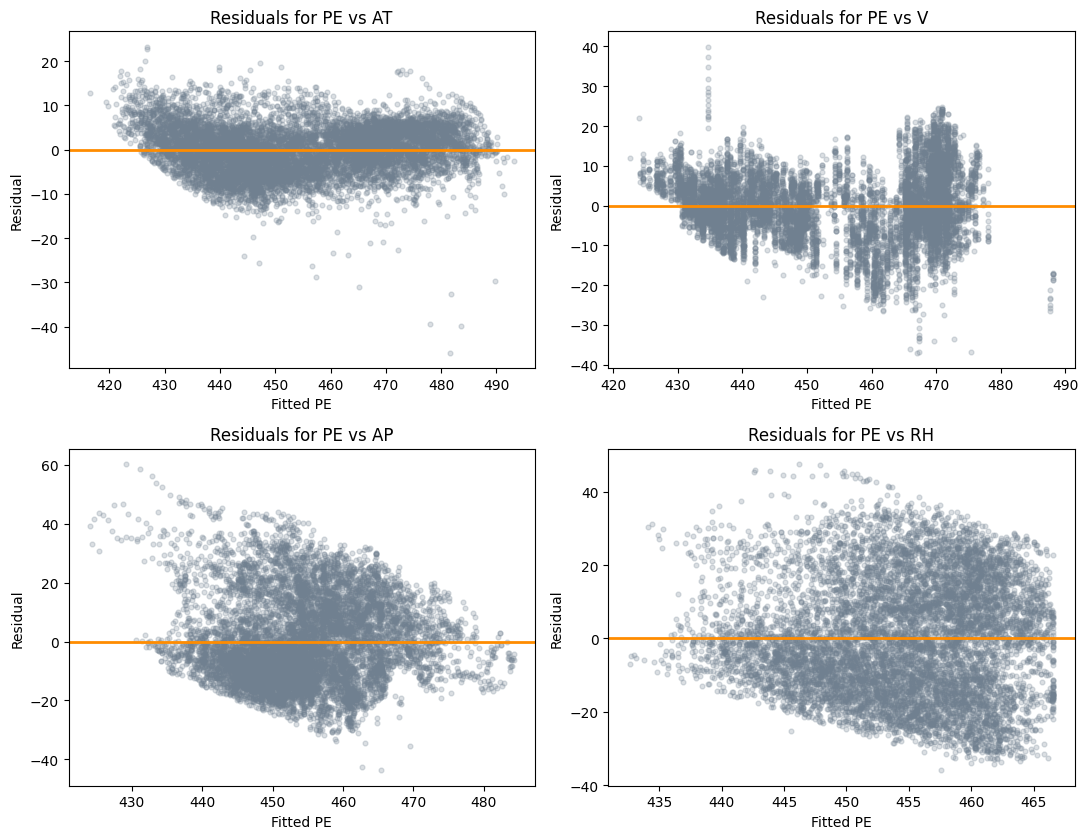

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for ax, p in zip(axes.ravel(), predictors):
    ax.scatter(results[p]["fitted"], results[p]["resid"], s=12, alpha=0.25, color="slategray")
    ax.axhline(0, color="darkorange", linewidth=2)
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")
    ax.set_title("Residuals for PE vs " + p)
plt.tight_layout()
plt.show()

In [9]:
for i in predictors:
    residuals = results[i]["resid"]
    standardized_residuals = residuals / residuals.std()
    number_of_outliers = (np.abs(standardized_residuals) > 4).sum()
    print(i, ":", number_of_outliers, "points with standardized residual above 4")

AT : 15 points with standardized residual above 4
V : 9 points with standardized residual above 4
AP : 2 points with standardized residual above 4
RH : 0 points with standardized residual above 4


All four predictors here turn out to be statistically significant on their own, with p-values well below 0.05 in every case. That being said, how well each one actually fits differs quite a bit. AT gives the strongest fit with an R2 around 0.899, followed by V at about 0.757. AP and RH trail behind at roughly 0.269 and 0.152, and their scatter plots reflect that, both are more spread out noticeably than AT and V.

And as for outliers here, a small number of points stand out in each model based on standardized residuals, around 15 for AT, 9 for V, 2 for AP, and none for RH. Since these are such a small share of the data and there's no indication anything is wrong with them, I chose to leave them in rather than remove them.

#### 1(d)

In [10]:
predictors = ["AT", "V", "AP", "RH"]
X = df[predictors].values
y = df["PE"].values
n = X.shape[0]
k = X.shape[1]
X_design = np.column_stack([np.ones(n), X])

coefficients, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
fitted_values = X_design @ coefficients
residuals = y - fitted_values
residual_sum_of_squares = np.sum(residuals ** 2)
sigma_squared = residual_sum_of_squares/(n - k - 1)
XtX_inverse = np.linalg.inv(X_design.T @ X_design)
standard_errors = np.sqrt(np.diag(sigma_squared*XtX_inverse))
t_statistics = (coefficients/standard_errors)
p_values = 2*(1 - stats.t.cdf(np.abs(t_statistics), df=n - k - 1))
total_sum_of_squares = np.sum((y-y.mean())**2)
r_squared = 1-residual_sum_of_squares/total_sum_of_squares

names = ["Intercept"] + predictors

multiple_regression = pd.DataFrame({"Coefficient": coefficients, "Standard Error": standard_errors, "T Statistic": t_statistics, "P Value": p_values}, index=names)
multiple_regression.round(4)

,Coefficient,Standard Error,T Statistic,P Value
Intercept,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


In [11]:
print("R-squared:", round(r_squared, 4))

R-squared: 0.9287


Here, all four predictors, AT, V, AP, and RH, come out statistically significant in the combined model, where each one lands comfortably under the 0.05 cutoff. Therefore, the null hypothesis that the coefficient is zero can be rejected for all four. AT still has the largest effect, with the biggest coefficient by far, followed by V and RH, while AP has a smaller effect but is still clearly significant. Seeing them together, the four predictors explain about 92.9 percent of the variance in PE, which is higher than any single predictor managed on its own in 1c.

#### 1(e)

In [12]:
simple_coefficients = {}

for i in predictors:
    reg = stats.linregress(df[i], df["PE"])
    simple_coefficients[i] = reg.slope

multiple_coefficients = dict(zip(predictors, coefficients[1:]))
comparison = pd.DataFrame({"Simple Regression Coefficient": simple_coefficients, "Multiple Regression Coefficient": multiple_coefficients})
comparison.round(4)

,Simple Regression Coefficient,Multiple Regression Coefficient
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


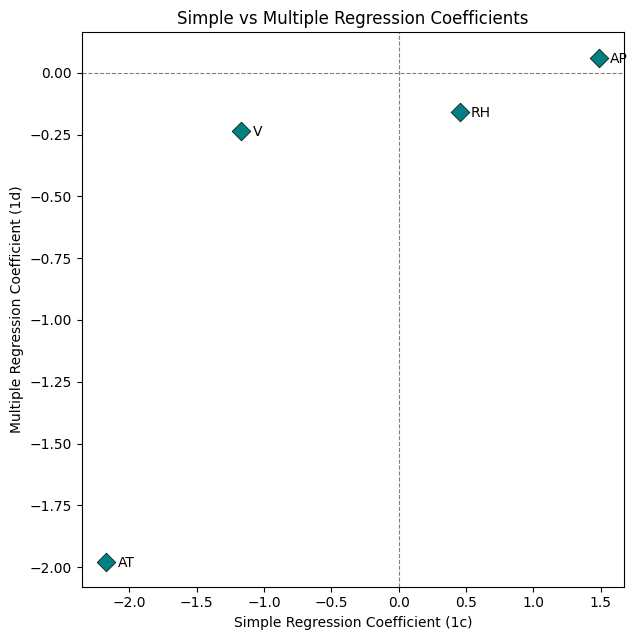

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in predictors:
    ax.scatter(simple_coefficients[i], multiple_coefficients[i], s=90, color="teal", marker="D", edgecolor="black", linewidth=0.5)
    ax.annotate(i, (simple_coefficients[i], multiple_coefficients[i]), textcoords="offset points", xytext=(8, -4), fontsize=10)


ax.set_xlabel("Simple Regression Coefficient (1c)")
ax.set_ylabel("Multiple Regression Coefficient (1d)")
ax.set_title("Simple vs Multiple Regression Coefficients")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

AT, V, and AP keep the same sign moving from simple to multiple regression, though their coefficients shrink somewhat once the other predictors are accounted for. RH here is the exception, as it is positive on its own but negative in the combined model, which shows up clearly in the plot as the only point that sits on the opposite side of zero. This flip happens because RH overlaps with the other predictors, so its standalone relationship with PE does not hold once they are included together.

#### 1(f)

In [14]:
cubic_results = {}

for i in predictors:
    x = df[i].values
    x_centered = x - x.mean()
    X_design = np.column_stack([np.ones(len(x_centered)), x_centered, x_centered**2, x_centered**3])
    n = X_design.shape[0]
    k = X_design.shape[1]-1
    coefficients, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
    fitted_values = X_design @ coefficients
    residuals = y-fitted_values

    residual_sum_of_squares = np.sum(residuals**2)
    sigma_squared = (residual_sum_of_squares/(n-k-1))
    XtX_inverse = np.linalg.inv(X_design.T @ X_design)
    standard_errors = np.sqrt(np.diag(sigma_squared*XtX_inverse))
    t_statistics = (coefficients/standard_errors)
    p_values = 2*(1-stats.t.cdf(np.abs(t_statistics), df=n-k-1))
    total_sum_of_squares = np.sum((y-y.mean())**2)
    r_squared = 1-residual_sum_of_squares/total_sum_of_squares

    cubic_results[i] = {"coefficients": coefficients, "p_values": p_values, "R2": r_squared}

    print(i)
    
    for name, coef, p_value in zip(["Intercept", "X", "X2", "X3"], coefficients, p_values):
        print("  " + name + ": coefficient =", round(coef, 6), " p-value =", round(p_value, 6))
        
    print("  R-squared:", round(r_squared, 4))
    print()

AT
  Intercept: coefficient = 452.708116  p-value = 0.0
  X: coefficient = -2.429734  p-value = 0.0
  X2: coefficient = 0.032554  p-value = 0.0
  X3: coefficient = 0.002675  p-value = 0.0
  R-squared: 0.9119

V
  Intercept: coefficient = 451.213736  p-value = 0.0
  X: coefficient = -1.250257  p-value = 0.0
  X2: coefficient = 0.019177  p-value = 0.0
  X3: coefficient = 0.000134  p-value = 0.013735
  R-squared: 0.775

AP
  Intercept: coefficient = 453.082345  p-value = 0.0
  X: coefficient = 1.964663  p-value = 0.0
  X2: coefficient = 0.044238  p-value = 0.0
  X3: coefficient = -0.004991  p-value = 0.0
  R-squared: 0.2975

RH
  Intercept: coefficient = 454.442962  p-value = 0.0
  X: coefficient = 0.53018  p-value = 0.0
  X2: coefficient = -0.001325  p-value = 0.101395
  X3: coefficient = -0.000152  p-value = 1.4e-05
  R-squared: 0.1537



Here, when we fit a cubic model separately for each predictor, the squared and cubed terms come out significant for AT and AP, both terms well below 0.05, which is strong evidence that their relationship with PE is not purely linear. V here also shows significant squared and cubed terms. RH is a bit different, its cubed term is significant but the squared term is not, so there is still some evidence of a nonlinear pattern, just a weaker one. By taking them together, all four predictors here show at least some evidence of nonlinear association with PE, not just AT and V which had the strongest linear fits in 1c.

#### 1(g)

In [15]:
from itertools import combinations

centered_predictors = {}

for i in predictors:
    centered_predictors[i] = df[i].values-df[i].values.mean()

interaction_columns = [np.ones(len(y))]

interaction_names = ["Intercept"]

for i in predictors:
    interaction_columns.append(centered_predictors[i])
    interaction_names.append(i)

for first, second in combinations(predictors, 2):
    interaction_columns.append(centered_predictors[first]*centered_predictors[second])
    interaction_names.append(first + ":" + second)

X_design = np.column_stack(interaction_columns)
n = X_design.shape[0]
k = X_design.shape[1]-1

coefficients, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
fitted_values = X_design @ coefficients
residuals = y - fitted_values
residual_sum_of_squares = np.sum(residuals**2)
sigma_squared = residual_sum_of_squares/(n-k-1)
XtX_inverse = np.linalg.inv(X_design.T @ X_design)
standard_errors = np.sqrt(np.diag(sigma_squared*XtX_inverse))
t_statistics = coefficients/standard_errors
p_values = 2*(1-stats.t.cdf(np.abs(t_statistics), df=n-k-1))
total_sum_of_squares = np.sum((y-y.mean())**2)
r_squared = 1-residual_sum_of_squares/total_sum_of_squares

interaction_model = pd.DataFrame({"Coefficient": coefficients, "P Value": p_values}, index=interaction_names)
interaction_model.round(6)

,Coefficient,P Value
Intercept,452.694579,0.000000
AT,-1.809235,0.000000
V,-0.298594,0.000000
AP,0.134004,0.000000
RH,-0.119503,0.000000
AT:V,0.020971,0.000000
AT:AP,0.001759,0.452051
AT:RH,-0.005230,0.000000
V:AP,0.006812,0.000000
V:RH,0.000839,0.086194


In [16]:
print("R-squared:", round(r_squared, 4))

R-squared: 0.9363


Here, all four main effects stay significant in this model. Among the six pairwise interaction terms, four come out significant: the AT and V interaction, AT and RH, V and AP, and AP and RH, while AT and AP, and V and RH, do not. So we can say that there is evidence that some predictors interact with each other in how they affect PE, not just acting independently. Adding these interaction terms also raises R-squared to about 0.936, up from 0.929 in the plain multiple regression from 1d.

#### 1(h)

In [17]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
y_train = train_df["PE"].values
y_test = test_df["PE"].values
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

Training rows: 6697
Test rows: 2871


In [18]:
train_columns_plain = [np.ones(len(train_df))]

for i in predictors:
    train_columns_plain.append(train_df[i].values)
    
X_train_plain = np.column_stack(train_columns_plain)

test_columns_plain = [np.ones(len(test_df))]

for i in predictors:
    test_columns_plain.append(test_df[i].values)
X_test_plain = np.column_stack(test_columns_plain)

coefficients_plain, _, _, _ = np.linalg.lstsq(X_train_plain, y_train, rcond=None)
train_mse_plain = np.mean((y_train - X_train_plain @ coefficients_plain)**2)
test_mse_plain = np.mean((y_test - X_test_plain @ coefficients_plain)**2)
print("Plain model train MSE:", round(train_mse_plain, 4))
print("Plain model test MSE:", round(test_mse_plain, 4))

Plain model train MSE: 20.5808
Plain model test MSE: 21.2399


In [19]:
train_means = {}

for i in predictors:
    train_means[i] = train_df[i].values.mean()

centered_train = {}
centered_test = {}
for i in predictors:
    centered_train[i] = train_df[i].values - train_means[i]
    centered_test[i] = test_df[i].values - train_means[i]

train_terms = {}
test_terms = {}

for i in predictors:
    train_terms[i] = centered_train[i]
    test_terms[i] = centered_test[i]

for first, second in combinations(predictors, 2):
    train_terms[first + ":" + second] = centered_train[first]*centered_train[second]
    test_terms[first + ":" + second] = centered_test[first]*centered_test[second]

for i in predictors:
    train_terms[i + "^2"] = centered_train[i]**2
    test_terms[i + "^2"] = centered_test[i]**2

print("Total candidate terms:", len(train_terms))

Total candidate terms: 14


In [20]:
def fit_pvalues(active_terms):
    columns = [np.ones(len(y_train))]
    for t in active_terms:
        columns.append(train_terms[t])
    X = np.column_stack(columns)
    n = X.shape[0]
    k = X.shape[1] - 1
    beta, _, _, _ = np.linalg.lstsq(X, y_train, rcond=None)
    residuals = y_train - X @ beta
    sigma_squared = np.sum(residuals**2)/(n-k-1)
    standard_errors = np.sqrt(np.diag(sigma_squared*np.linalg.inv(X.T @ X)))
    t_statistics = (beta/standard_errors)
    p_values = 2*(1-stats.t.cdf(np.abs(t_statistics), df=n-k-1))
    return dict(zip(["Intercept"] + active_terms, p_values))

In [21]:
active_terms = list(train_terms.keys())

while True:
    p_values = fit_pvalues(active_terms)
    insignificant = {t: p_values[t] for t in active_terms if p_values[t] >= 0.05}
    
    if len(insignificant) == 0:
        break
        
    worst_term = max(insignificant, key=insignificant.get)
    print("Dropping", worst_term, "with p-value", round(insignificant[worst_term], 4))
    active_terms.remove(worst_term)


print()
print("Final terms kept:", active_terms)

Dropping V:RH with p-value 0.8674
Dropping V^2 with p-value 0.6077
Dropping V:AP with p-value 0.3578

Final terms kept: ['AT', 'V', 'AP', 'RH', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH', 'AT^2', 'AP^2', 'RH^2']


In [22]:
final_columns = [np.ones(len(y_train))]

for t in active_terms:
    final_columns.append(train_terms[t])
X_train_reduced = np.column_stack(final_columns)

n = X_train_reduced.shape[0]
k = X_train_reduced.shape[1] - 1
coefficients_reduced, _, _, _ = np.linalg.lstsq(X_train_reduced, y_train, rcond=None)
residuals_reduced = y_train - X_train_reduced @ coefficients_reduced
sigma_squared = np.sum(residuals_reduced**2)/(n-k-1)
standard_errors = np.sqrt(np.diag(sigma_squared * np.linalg.inv(X_train_reduced.T @ X_train_reduced)))
t_statistics = (coefficients_reduced/standard_errors)
p_values_reduced = 2*(1-stats.t.cdf(np.abs(t_statistics), df=n-k-1))

reduced_model = pd.DataFrame({"Coefficient": coefficients_reduced, "P Value": p_values_reduced}, index=["Intercept"] + active_terms)
reduced_model.round(6)

,Coefficient,P Value
Intercept,453.227507,0.000000
AT,-1.817267,0.000000
V,-0.298531,0.000000
AP,0.116926,0.000000
RH,-0.125096,0.000000
AT:V,0.008246,0.000000
AT:AP,0.006975,0.001508
AT:RH,-0.005537,0.000000
AP:RH,-0.003407,0.000297
AT^2,0.019534,0.000000


In [23]:
final_test_columns = [np.ones(len(y_test))]

for t in active_terms:
    final_test_columns.append(test_terms[t])
X_test_reduced = np.column_stack(final_test_columns)

train_mse_reduced = np.mean((y_train - X_train_reduced @ coefficients_reduced)**2)
test_mse_reduced = np.mean((y_test - X_test_reduced @ coefficients_reduced)**2)
print("Reduced model train MSE:", round(train_mse_reduced, 4))
print("Reduced model test MSE:", round(test_mse_reduced, 4))

Reduced model train MSE: 17.8908
Reduced model test MSE: 18.66


After splitting the data 70/30, the plain model with all four predictors gives a train MSE of about 20.58 and a test MSE of about 21.24. The second model began as a full model containing all four predictors, all six pairwise interactions, and a quadratic term for each predictor, with insignificant terms then removed one at a time by p-value, refitting after every drop. The order of removal ends up mattering here, since the interaction between AT and AP appears insignificant in the full model but becomes significant once the weak V terms are removed, those being the V and RH interaction, V squared, and the V and AP interaction. That interaction is therefore kept. The final model retains all four main effects, the interactions between AT and V, AT and AP, AT and RH, and AP and RH, along with the AT, AP, and RH quadratic terms. It gives a train MSE of about 17.89 and a test MSE of about 18.66, both lower than the plain model, so the interaction and quadratic terms do end up improving the fit.

#### 1(i)

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X_train_raw = train_df[predictors].values
X_test_raw = test_df[predictors].values
feature_means = X_train_raw.mean(axis=0)
feature_stds = X_train_raw.std(axis=0)
X_train_normalized = (X_train_raw-feature_means)/feature_stds
X_test_normalized = (X_test_raw-feature_means)/feature_stds

In [25]:
k_values = list(range(1, 101))

def knn_errors(X_train_features, X_test_features):
    
    train_errors = []
    test_errors = []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train_features, y_train)
        train_errors.append(mean_squared_error(y_train, knn.predict(X_train_features)))
        test_errors.append(mean_squared_error(y_test, knn.predict(X_test_features)))
        
    return train_errors, test_errors


raw_train_errors, raw_test_errors = knn_errors(X_train_raw, X_test_raw)
normalized_train_errors, normalized_test_errors = knn_errors(X_train_normalized, X_test_normalized)

In [26]:
best_k_raw = k_values[np.argmin(raw_test_errors)]
best_k_normalized = k_values[np.argmin(normalized_test_errors)]
print("Raw features: best k =", best_k_raw, " test MSE =", round(min(raw_test_errors), 4))
print("Normalized features: best k =", best_k_normalized, " test MSE =", round(min(normalized_test_errors), 4))

Raw features: best k = 5  test MSE = 15.7268
Normalized features: best k = 4  test MSE = 14.3057


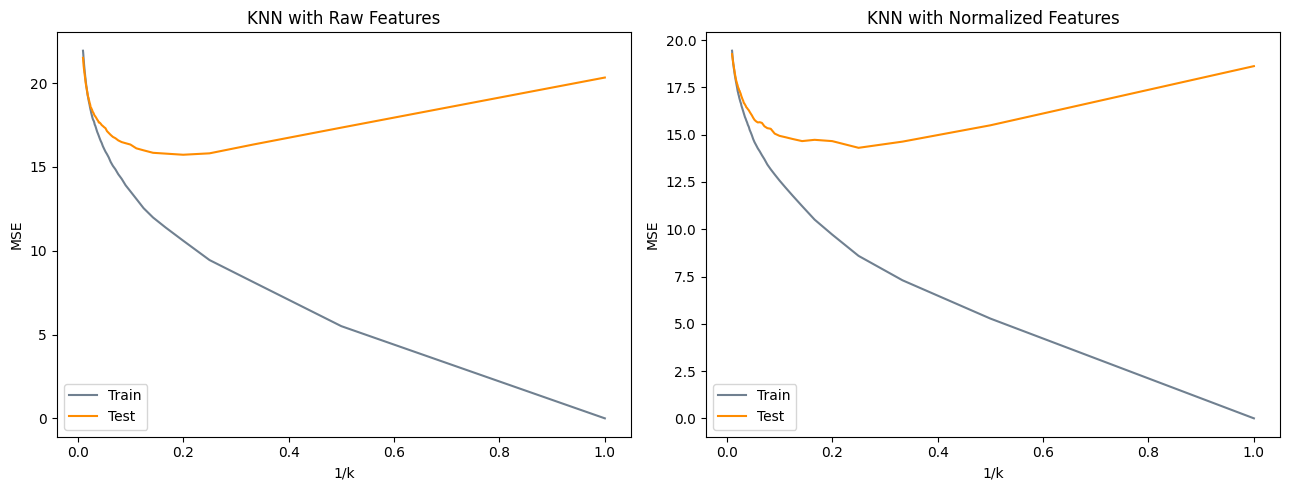

In [27]:
inverse_k = []

for k in k_values:
    inverse_k.append(1 / k)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(inverse_k, raw_train_errors, label="Train", color="slategray")
axes[0].plot(inverse_k, raw_test_errors, label="Test", color="darkorange")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].set_title("KNN with Raw Features")
axes[0].legend()

axes[1].plot(inverse_k, normalized_train_errors, label="Train", color="slategray")
axes[1].plot(inverse_k, normalized_test_errors, label="Test", color="darkorange")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].set_title("KNN with Normalized Features")
axes[1].legend()

plt.tight_layout()
plt.show()

The best fit comes at k = 5 for raw features, with a test MSE of about 15.73, and at k = 4 for normalized features, with a test MSE of about 14.31.

#### 1(j)

In [28]:
print("Best linear model test MSE:", round(test_mse_reduced, 4))
print("Best KNN model test MSE:", round(min(normalized_test_errors), 4))

Best linear model test MSE: 18.66
Best KNN model test MSE: 14.3057


Among the models tested on a held-out set here, the one with the smallest test error is the interaction and quadratic model from 1(h), at a test MSE of about 18.66. The best KNN model, using normalized features at k = 4, does better, with a test MSE of about 14.31. So KNN comes out ahead on test error for this dataset. This happens because KNN estimates each prediction from the closest points around it, which lets it follow the local structure of the data on its own, no matter what shape that structure takes. A linear model can only respond to curvature or interactions that were deliberately built into it as extra terms, and even with several of those added manually, it still falls short of the flexibility KNN has by default. What the linear model offers here in return is clarity. Its coefficients directly describe how each predictor influences the output, whereas KNN provides no such insight and leans heavily on proper feature scaling and a well-chosen k. In short, KNN is the stronger performer on test error here, while the linear model remains the easier one to interpret and explain.

### Problem-2

#### 2.4.1 (a)

Here, we can expect the performance of a flexible statistical learning method to be better. When n is this large compared to p, there's enough data for a flexible method to actually capture the underlying pattern instead of overfitting to noise, and that large number of observations offsets the variance that extra flexibility would normally bring.

#### 2.4.1 (b)

Here, we can expect the performance of a flexible statistical learning method to be worse. With p this large and n this small, a flexible method has far more room to fit the training data exactly, noise included, since there are so few observations to hold it in check relative to the number of predictors. This pushes variance up sharply. A less flexible method that leans on a simpler structure tends to generalize better instead.

#### 2.4.1 (c)

Here, we can expect the performance of a flexible statistical learning method to be better. An inflexible method such as linear regression locks in a fixed and simple functional form. When the actual relationship is highly non-linear here, that assumption creates substantial bias no matter how much data you have. A flexible method can bend along the real curvature of the relationship and cut that bias down.

#### 2.4.1 (d)

Here, we can expect the performance of a flexible statistical learning method to be worse. When the error variance is this high, most of the variation in the response is just noise that no method can actually predict. A flexible method here ends up treating that noise as signal and fitting it anyway, which drives variance up without any real gain in accuracy. A less flexible method, on the other hand, sticks closer to the average trend and stays less thrown off by it.

### Problem-3

#### 2.4.7 (a)

In [29]:
observations = pd.DataFrame({"X1": [0, 2, 0, 0, -1, 1], "X2": [3, 0, 1, 1, 0, 1], "X3": [0, 0, 3, 2, 1, 1], "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]}, index=[1, 2, 3, 4, 5, 6])
test_point = np.array([0, 0, 0])

distances = []
for i in observations.index:
    predictor_values = observations.loc[i, ["X1", "X2", "X3"]].values.astype(float)
    distance = np.sqrt(np.sum((predictor_values-test_point)**2))
    distances.append(distance)


observations["Distance"] = distances
observations.round(4)

,X1,X2,X3,Y,Distance
1,0,3,0,Red,3.0000
2,2,0,0,Red,2.0000
3,0,1,3,Red,3.1623
4,0,1,2,Green,2.2361
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321


#### 2.4.7 (b)

Here, setting K equal to 1 gives a prediction of Green. Observation 5 here is the nearest neighbor to the test point, at a distance of about 1.4142, so its response alone determines the prediction, which comes out to be Green.

#### 2.4.7 (c)

Here, setting K equal to 3 gives a prediction of Red. The three nearest neighbors to the test point turn out to be observations 5, 6, and 2, with distances of about 1.4142, 1.7321, and 2. Since two of those three, observations 6 and 2 here, are Red, the majority vote lands on Red as the prediction.

#### 2.4.7 (d)

Here, the best K would likely be small. A small K keeps the prediction tied to the immediate local neighborhood, which lets the boundary bend and twist to match a pattern that's highly non-linear. A large K draws in observations from farther away instead , which smooths everything out and drags the boundary toward a more linear shape, which is the opposite of what is needed when the true Bayes decision boundary is far from being linear.